In [1]:
from pathlib import Path

import celltypist
import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse
from scipy.stats import median_abs_deviation
import numpy as np

# Set Base directory to the location of this script
BASE = Path('c:/Users/ankit/Documents/scFM/train_data/')

# Set working directory to the location of this script 
# data_dir = BASE / 'h5s_common_directory_WIP'
data_dir = BASE / 'scGPT_data'

# Print contents of the data directory for verification
print(f"Contents of data directory ({data_dir}):")
for item in data_dir.iterdir():
    print(item.name)

c:\Users\ankit\miniconda3\envs\celltypist\Lib\site-packages\celltypist\classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


Contents of data directory (c:\Users\ankit\Documents\scFM\train_data\scGPT_data):
GSE159977.h5ad
GSE174748.h5ad
GSE185477.h5ad
GSE189600.h5ad
GSE190487.h5ad
GSE192740.h5ad
GSE202379.h5ad
GSE212837.h5ad
GSE270488.h5ad


In [3]:
# Read in each h5ad file with the Anndata object variable name being it's file name without the extension and store in dictionary
adata_dict_liver = {}
adata_dict_immune = {}

liver_gses = [
    "GSE212837",
    "GSE189600",
    "GSE174748",
    "GSE192740",
    "GSE185477",
    "GSE202379"
]

liver_gses = ["GSE192740"]

immmune_gses = [
    "GSE270488",
    "GSE159977",
    "GSE190487",
    "GSE192740"
]
immmune_gses = []

for h5ad_file in data_dir.glob('*.h5ad'):
    adata_name = h5ad_file.stem  # Get file name without extension

    if adata_name in liver_gses:
        adata_dict_liver[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary
        print(f"Adding {adata_name} to liver")

    if adata_name in immmune_gses:
        adata_dict_immune[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary
        print(f"Adding {adata_name} to immune")





Adding GSE192740 to liver


In [7]:
print(adata.obs.cellcall.head())

0      CD8 TRM
1    GD T cell
2      CD8 TRM
3      CD8 TRM
4      CD8 TRM
Name: cellcall, dtype: category
Categories (10, object): ['CD4 Naive/TCM', 'CD4 TEM', 'CD4 Th17', 'CD8 Naive/TCM', ..., 'CD8 TRM', 'GD T cell', 'MAIT', 'Treg']


In [4]:
print(adata_dict_liver["GSE212837"].shape)

(182302, 33557)


In [5]:
import celltypist
from celltypist import models

In [9]:
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in C:\Users\ankit\.celltypist\data\models
💾 Downloading model [1/61]: Immune_All_Low.pkl
💾 Downloading model [2/61]: Immune_All_High.pkl
💾 Downloading model [3/61]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/61]: Adult_Human_MTG.pkl
💾 Downloading model [6/61]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/61]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/61]: Adult_Human_Skin.pkl
💾 Downloading model [9/61]: Adult_Human_Vascular.pkl
💾 Downloading model [10/61]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/61]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/61]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/61]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/61]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/61]: Adult_cHSPCs_Ultima.pkl
💾 

Check datasets for duplicate cells

In [10]:
for name, adata in adata_dict_immune.items():
    print(name)
    print(f"Duplicate cells before: {adata.obs.index.duplicated().sum()}")
    
    # Remove duplicate cells if they exist
    if adata.obs.index.duplicated().any():
        adata = adata[~adata.obs.index.duplicated(keep='first')]
        adata_dict_immune[name] = adata
    
    print(f"Duplicate cells after: {adata.obs.index.duplicated().sum()}")


GSE159977
Duplicate cells before: 3609
Duplicate cells after: 0
GSE190487
Duplicate cells before: 0
Duplicate cells after: 0
GSE192740
Duplicate cells before: 0
Duplicate cells after: 0
GSE270488
Duplicate cells before: 0
Duplicate cells after: 0


In [11]:
for name, adata in adata_dict_liver.items():
    print(name)
    print(f"Duplicate cells before: {adata.obs.index.duplicated().sum()}")
    
    # Remove duplicate cells if they exist
    if adata.obs.index.duplicated().any():
        adata = adata[~adata.obs.index.duplicated(keep='first')]
        adata_dict_immune[name] = adata
    
    print(f"Duplicate cells after: {adata.obs.index.duplicated().sum()}")


GSE174748
Duplicate cells before: 0
Duplicate cells after: 0
GSE185477
Duplicate cells before: 0
Duplicate cells after: 0
GSE189600
Duplicate cells before: 0
Duplicate cells after: 0
GSE192740
Duplicate cells before: 0
Duplicate cells after: 0
GSE202379
Duplicate cells before: 0
Duplicate cells after: 0
GSE212837
Duplicate cells before: 0
Duplicate cells after: 0


## Add immune annotations to immune datasets

In [5]:
model = models.Model.load(model = 'Immune_All_Low.pkl')

In [6]:
model

CellTypist model with 98 cell types and 6639 features
    date: 2022-07-16 00:20:42.927778
    details: immune sub-populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: Age-associated B cells, Alveolar macrophages, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX

In [ ]:
for name, adata in adata_dict_immune.items():
    print(name)
    
    # Skip if already annotated
    if any(col.startswith("typist_immune_") for col in adata.obs.columns):
        print("Already annotated with typist_immune_, skipping...")
        print()
        continue
    
    print()
    predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)
    adata = predictions.to_adata(prefix="typist_immune_", insert_conf_by="majority_voting")
    adata_dict_immune[name] = adata
    print(adata.obs["typist_immune_majority_voting"].head())
    print(adata.obs["typist_immune_conf_score"].head())

GSE159977



🔬 Input data has 103242 cells and 23993 genes
🔗 Matching reference genes in the model
🧬 5470 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 25
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 41995 cells and 19059 genes
🔗 Matching reference genes in the model


AAACCCAAGCATATGA-1                 CD16- NK cells
AAACCCACAACGGCTC-1    Tem/Temra cytotoxic T cells
AAACCCAGTATTCCGA-1                 CD16- NK cells
AAACCCAGTTAAGACA-1      Tem/Trm cytotoxic T cells
AAACGAAAGTTGTAGA-1                     MAIT cells
Name: typist_immune_majority_voting, dtype: category
Categories (23, object): ['CD16+ NK cells', 'CD16- NK cells', 'CRTAM+ gamma-delta T cells', 'Classical monocytes', ..., 'Tem/Temra cytotoxic T cells', 'Tem/Trm cytotoxic T cells', 'Trm cytotoxic T cells', 'pDC']
AAACCCAAGCATATGA-1    0.999962
AAACCCACAACGGCTC-1    0.201259
AAACCCAGTATTCCGA-1    0.999995
AAACCCAGTTAAGACA-1    0.952672
AAACGAAAGTTGTAGA-1    0.994775
Name: typist_immune_conf_score, dtype: float64
GSE190487



🧬 5531 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 69758 cells and 30704 genes
🔗 Matching reference genes in the model


barcode
AAACCCAAGACGAAGA-1    Memory B cells
AAACCCAAGACTCTAC-1    Memory B cells
AAACCCAAGAGAGGTA-1        Myelocytes
AAACCCAAGAGCAGAA-1    Memory B cells
AAACCCAAGATGTAGT-1    Memory B cells
Name: typist_immune_majority_voting, dtype: category
Categories (6, object): ['Memory B cells', 'Myelocytes', 'NK cells', 'Naive B cells', 'Plasma cells', 'Tcm/Naive helper T cells']
barcode
AAACCCAAGACGAAGA-1    0.003851
AAACCCAAGACTCTAC-1    0.124588
AAACCCAAGAGAGGTA-1    0.048412
AAACCCAAGAGCAGAA-1    0.002876
AAACCCAAGATGTAGT-1    0.441437
Name: typist_immune_conf_score, dtype: float64
GSE192740



🧬 5263 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 18376 cells and 21251 genes
🔗 Matching reference genes in the model


CS110_AAACCCACACGGTGTC-1-0    Erythrophagocytic macrophages
CS110_AAACCCACAGTCAGTT-1-0                   CD16- NK cells
CS110_AAACCCACATTGCAAC-1-0                       MAIT cells
CS110_AAACCCAGTGTGCTTA-1-0                       MAIT cells
CS110_AAACCCAGTGTTCATG-1-0                   CD16- NK cells
Name: typist_immune_majority_voting, dtype: category
Categories (27, object): ['Alveolar macrophages', 'B cells', 'CD16+ NK cells', 'CD16- NK cells', ..., 'Tem/Effector helper T cells', 'Tem/Temra cytotoxic T cells', 'Tem/Trm cytotoxic T cells', 'pDC']
CS110_AAACCCACACGGTGTC-1-0    0.892503
CS110_AAACCCACAGTCAGTT-1-0    0.999591
CS110_AAACCCACATTGCAAC-1-0    0.978611
CS110_AAACCCAGTGTGCTTA-1-0    0.999969
CS110_AAACCCAGTGTTCATG-1-0    0.056139
Name: typist_immune_conf_score, dtype: float64
GSE270488



🧬 5316 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


0    Tem/Trm cytotoxic T cells
1    Tem/Trm cytotoxic T cells
2    Tem/Trm cytotoxic T cells
3     Tcm/Naive helper T cells
4    Tem/Trm cytotoxic T cells
Name: typist_immune_majority_voting, dtype: category
Categories (10, object): ['CD16- NK cells', 'CRTAM+ gamma-delta T cells', 'Follicular helper T cells', 'MAIT cells', ..., 'Tem/Effector helper T cells', 'Tem/Temra cytotoxic T cells', 'Tem/Trm cytotoxic T cells', 'Trm cytotoxic T cells']
0    0.000316
1    0.774184
2    0.009168
3    0.003769
4    0.998790
Name: typist_immune_conf_score, dtype: float64


## Adding Liver

In [6]:
model = models.Model.load(model = 'Healthy_Human_Liver.pkl')

In [7]:
model

CellTypist model with 17 cell types and 2691 features
    date: 2023-09-14 12:48:54.179790
    details: cell types from scRNA-seq and snRNA-seq of the adult human liver
    source: https://doi.org/10.1016/j.cell.2021.12.018
    version: v1
    cell types: B cells, Basophils, ..., pDCs
    features: HES4, TNFRSF18, ..., MT-CYB

In [8]:
for name, adata in adata_dict_liver.items():
    print(name)
    
    # Skip if already annotated
    if any(col.startswith("typist_liver_") for col in adata.obs.columns):
        print("Already annotated with typist_liver_, skipping...")
        print()
        continue
    
    print()
    predictions = celltypist.annotate(adata, model = 'Healthy_Human_Liver.pkl', majority_voting = True)
    adata = predictions.to_adata(prefix="typist_liver_", insert_conf_by="majority_voting")
    adata_dict_liver[name] = adata
    print(adata.obs["typist_liver_majority_voting"].head())
    print(adata.obs["typist_liver_conf_score"].head())

🔬 Input data has 69758 cells and 30704 genes
🔗 Matching reference genes in the model


GSE192740



🧬 2688 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


CS110_AAACCCACACGGTGTC-1-0    Macrophages
CS110_AAACCCACAGTCAGTT-1-0    Resident NK
CS110_AAACCCACATTGCAAC-1-0        T cells
CS110_AAACCCAGTGTGCTTA-1-0        T cells
CS110_AAACCCAGTGTTCATG-1-0    Resident NK
Name: typist_liver_majority_voting, dtype: category
Categories (16, object): ['B cells', 'Basophils', 'Cholangiocytes', 'Circulating NK/NKT', ..., 'T cells', 'cDC1s', 'cDC2s', 'pDCs']
CS110_AAACCCACACGGTGTC-1-0    1.000000
CS110_AAACCCACAGTCAGTT-1-0    0.999957
CS110_AAACCCACATTGCAAC-1-0    0.999873
CS110_AAACCCAGTGTGCTTA-1-0    0.999996
CS110_AAACCCAGTGTTCATG-1-0    0.000215
Name: typist_liver_conf_score, dtype: float64


In [44]:
import pandas as pd

ct = pd.crosstab(
    adata.obs["cellcall"],
    adata.obs["typist_majority_voting"],
    margins=True
)

ct

typist_majority_voting,CD16- NK cells,CRTAM+ gamma-delta T cells,Follicular helper T cells,MAIT cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,Trm cytotoxic T cells,All
cellcall,,,,,,,,,,,
CD4 Naive/TCM,0,8,141,1,60,156,173,8,130,1,678
CD4 TEM,0,11,386,68,323,161,1324,125,1077,48,3523
CD4 Th17,0,0,0,25,0,1,186,0,9,0,221
CD8 Naive/TCM,0,1,0,1,2,64,89,2,107,36,302
CD8 TEM,62,1855,28,0,64,9,50,445,2489,62,5064
CD8 TEMRA,1,32,0,0,0,0,0,37,17,0,87
CD8 TRM,14,398,158,42,139,29,200,283,4807,81,6151
GD T cell,130,546,0,92,0,1,37,605,345,0,1756
MAIT,0,1,0,328,0,0,18,1,6,0,354


In [45]:
ct_prop = pd.crosstab(
    adata.obs["cellcall"],
    adata.obs["typist_majority_voting"],
    normalize="index"
) * 100

ct_prop.round(1)

typist_majority_voting,CD16- NK cells,CRTAM+ gamma-delta T cells,Follicular helper T cells,MAIT cells,Regulatory T cells,Tcm/Naive helper T cells,Tem/Effector helper T cells,Tem/Temra cytotoxic T cells,Tem/Trm cytotoxic T cells,Trm cytotoxic T cells
cellcall,,,,,,,,,,
CD4 Naive/TCM,0.0,1.2,20.8,0.1,8.8,23.0,25.5,1.2,19.2,0.1
CD4 TEM,0.0,0.3,11.0,1.9,9.2,4.6,37.6,3.5,30.6,1.4
CD4 Th17,0.0,0.0,0.0,11.3,0.0,0.5,84.2,0.0,4.1,0.0
CD8 Naive/TCM,0.0,0.3,0.0,0.3,0.7,21.2,29.5,0.7,35.4,11.9
CD8 TEM,1.2,36.6,0.6,0.0,1.3,0.2,1.0,8.8,49.2,1.2
CD8 TEMRA,1.1,36.8,0.0,0.0,0.0,0.0,0.0,42.5,19.5,0.0
CD8 TRM,0.2,6.5,2.6,0.7,2.3,0.5,3.3,4.6,78.1,1.3
GD T cell,7.4,31.1,0.0,5.2,0.0,0.1,2.1,34.5,19.6,0.0
MAIT,0.0,0.3,0.0,92.7,0.0,0.0,5.1,0.3,1.7,0.0


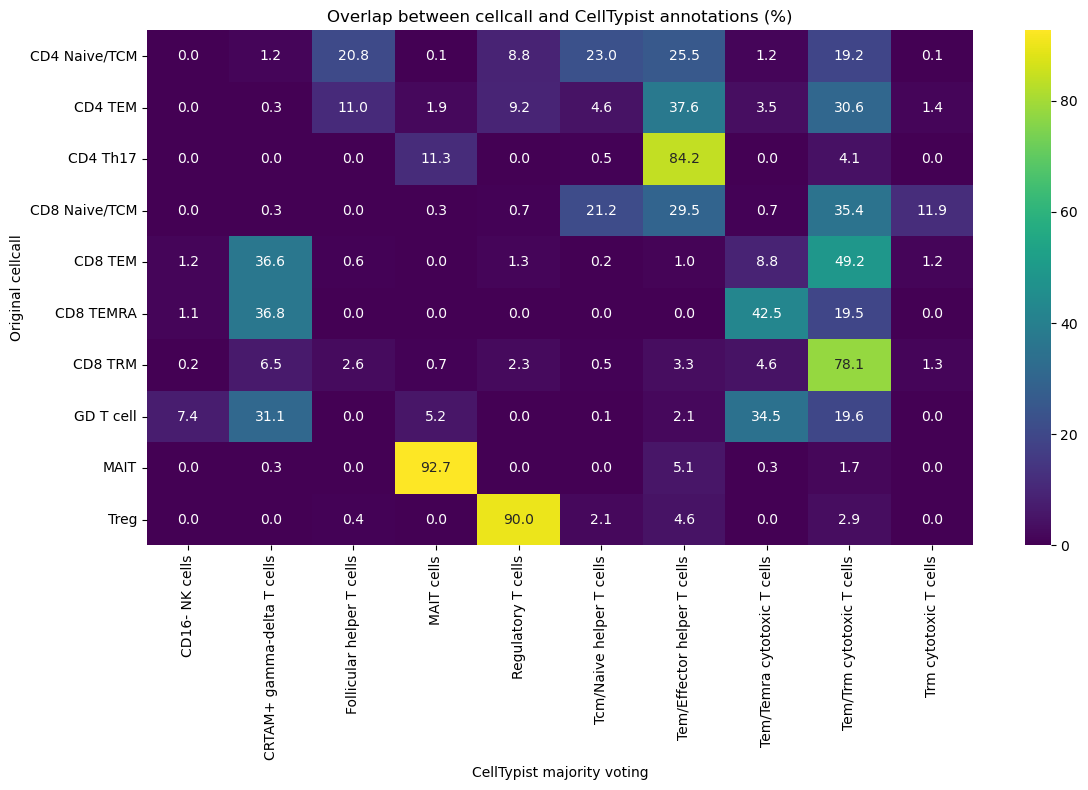

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(ct_prop, annot=True, fmt=".1f", cmap="viridis")
plt.xlabel("CellTypist majority voting")
plt.ylabel("Original cellcall")
plt.title("Overlap between cellcall and CellTypist annotations (%)")
plt.tight_layout()
plt.show()

In [9]:
# Save each anndata object in the dictionary to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'

output_dir = BASE / 'scGPT_data'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
for name, adata in adata_dict_liver.items():
    output_file = output_dir / f"{name}.h5ad"
    adata.write_h5ad(output_file)
    print(f"Saved {name} to {output_file}")

for name, adata in adata_dict_immune.items():
    output_file = output_dir / f"{name}.h5ad"
    adata.write_h5ad(output_file)
    print(f"Saved {name} to {output_file}")

Saved GSE192740 to c:\Users\ankit\Documents\scFM\train_data\scGPT_data\GSE192740.h5ad
